# Synthetic Population: Win-Rate Matrix in the Infinite-Sample Limit

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit

## Synthetic population

Sample utilities  for  voters and  candidates from a standard normal.
Voters are weighted uniformly.

In [17]:
M = 10  # candidates
N = 10  # voters
beta = 1.0
rng = np.random.default_rng(42)

utilities = rng.standard_normal((N, M))   # shape (N, M)
voter_dist = np.ones(N, dtype=float) / N  # uniform

avg_utilities = voter_dist @ utilities    # shape (M,)
true_ranking  = np.argsort(-avg_utilities)

print("utilities shape:", utilities.shape)
print("avg_utilities:", np.round(avg_utilities, 3))
print("true ranking (best to worst):", true_ranking)

utilities shape: (10, 10)
avg_utilities: [ 0.234 -0.24  -0.214  0.163 -0.368 -0.128 -0.106 -0.132  0.263  0.025]
true ranking (best to worst): [8 0 3 9 6 5 7 2 1 4]


## Win-rate matrix: infinite-sample limit

Under the Bradley-Terry model with inverse temperature , the probability that
candidate  beats candidate  in a comparison drawn from voter  is
. Averaging over voters gives the population win-rate:

431617P[i,j] = \sum_v w_v \,\sigma\!\left(\beta(u_{vi}-u_{vj})\right)431617

This is the matrix an empirical win-rate matrix converges to as the number of
pairwise samples grows to infinity.

In [18]:
def win_rate_matrix(utilities, voter_dist, beta=1.0):
    V, C = utilities.shape
    P = np.zeros((C, C), dtype=float)
    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]   # (C, C)
        P += voter_dist[v] * expit(beta * diffs)
    np.fill_diagonal(P, 0.5)
    return P


P = win_rate_matrix(utilities, voter_dist, beta=beta)

print("P shape:", P.shape)
print("row sums (should all be ~M/2 = 5.0):", np.round(P.sum(axis=1), 3))

P shape: (10, 10)
row sums (should all be ~M/2 = 5.0): [5.558 4.594 4.65  5.442 4.365 4.839 4.891 4.81  5.704 5.146]


## Visualisation

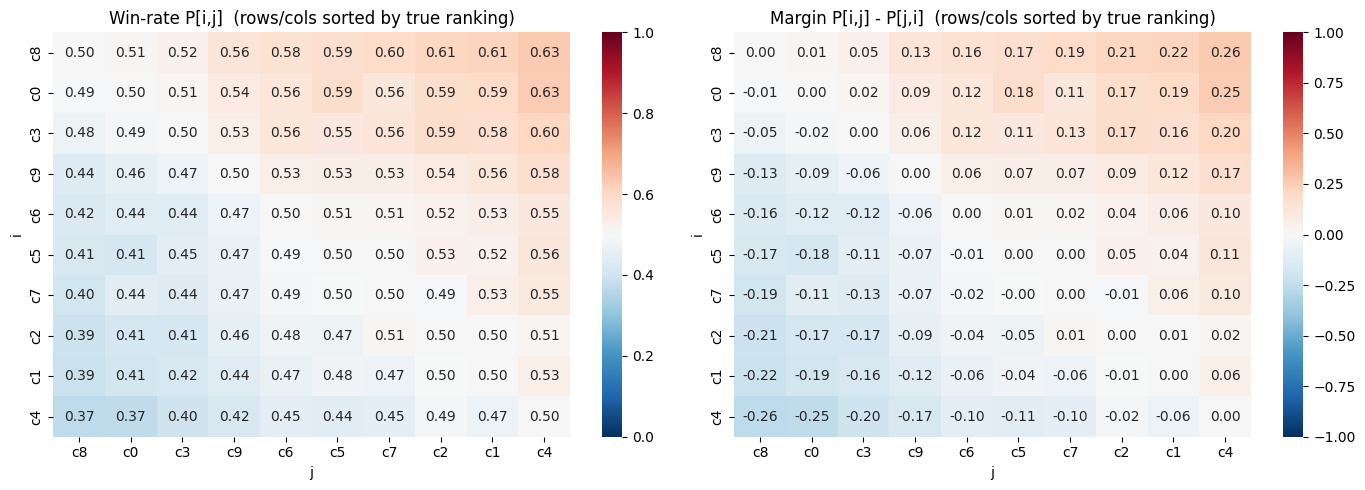

In [19]:
candidate_labels = [f"c{i}" for i in range(M)]
ordered = true_ranking  # sort rows/cols by true ranking for readability

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# raw win-rate matrix
ax = axes[0]
sns.heatmap(
    P[np.ix_(ordered, ordered)],
    ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", vmin=0, vmax=1,
    xticklabels=[candidate_labels[i] for i in ordered],
    yticklabels=[candidate_labels[i] for i in ordered],
)
ax.set_title("Win-rate P[i,j]  (rows/cols sorted by true ranking)")
ax.set_xlabel("j")
ax.set_ylabel("i")

# margin matrix P - P.T
margin = P - P.T
ax = axes[1]
sns.heatmap(
    margin[np.ix_(ordered, ordered)],
    ax=ax, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
    xticklabels=[candidate_labels[i] for i in ordered],
    yticklabels=[candidate_labels[i] for i in ordered],
)
ax.set_title("Margin P[i,j] - P[j,i]  (rows/cols sorted by true ranking)")
ax.set_xlabel("j")
ax.set_ylabel("i")

plt.tight_layout()
plt.show()

In [20]:
pairs = [(i, j) for i in range(M) for j in range(i + 1, M)]
consistent = sum(
    (avg_utilities[i] > avg_utilities[j]) == (P[i, j] > 0.5)
    for i, j in pairs
)
print(f"Pairs where win-rate agrees with avg-utility order: {consistent}/{len(pairs)}")
print("P:\n", np.round(P, 3))
print("Margin (P - P.T):\n", np.round(margin, 3))

Pairs where win-rate agrees with avg-utility order: 44/45
P:
 [[0.5   0.594 0.586 0.512 0.625 0.589 0.561 0.556 0.493 0.543]
 [0.406 0.5   0.496 0.418 0.529 0.478 0.468 0.471 0.388 0.44 ]
 [0.414 0.504 0.5   0.413 0.511 0.474 0.48  0.506 0.394 0.456]
 [0.488 0.582 0.587 0.5   0.602 0.553 0.561 0.563 0.475 0.53 ]
 [0.375 0.471 0.489 0.398 0.5   0.445 0.448 0.451 0.371 0.417]
 [0.411 0.522 0.526 0.447 0.555 0.5   0.494 0.502 0.414 0.467]
 [0.439 0.532 0.52  0.439 0.552 0.506 0.5   0.51  0.422 0.47 ]
 [0.444 0.529 0.494 0.437 0.549 0.498 0.49  0.5   0.403 0.467]
 [0.507 0.612 0.606 0.525 0.629 0.586 0.578 0.597 0.5   0.564]
 [0.457 0.56  0.544 0.47  0.583 0.533 0.53  0.533 0.436 0.5  ]]
Margin (P - P.T):
 [[ 0.     0.188  0.172  0.023  0.251  0.178  0.122  0.112 -0.015  0.087]
 [-0.188  0.    -0.008 -0.164  0.057 -0.045 -0.063 -0.057 -0.225 -0.121]
 [-0.172  0.008  0.    -0.175  0.021 -0.052 -0.041  0.011 -0.213 -0.088]
 [-0.023  0.164  0.175  0.     0.203  0.107  0.121  0.126 -0.05   0.0

## Rankings and distortions across beta

In [21]:
import sys
sys.path.insert(0, '/home/jennifer/distortion')
from utils_3 import (
    argmax_lottery_from_population_utilities,
    nonzero_max_from_population_utilities,
    leaderboard_dist,
)

In [22]:
def borda_from_P(P, cand_dist):
    """Borda score for each candidate: expected win prob against a cand_dist-weighted opponent."""
    scores = P @ cand_dist  # score[i] = sum_j P[i,j] * cand_dist[j]
    return np.argsort(-scores)


def borda_peeling_from_P(P, cand_dist):
    """Borda with peeling: at each round restrict to remaining candidates, reweight cand_dist."""
    C = P.shape[0]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P_rem = P[np.ix_(rem, rem)]
        cd_rem = cand_dist[rem] / cand_dist[rem].sum()
        scores = P_rem @ cd_rem  # score[i] = sum_j P[i,j] * cand_dist[j]
        winner_local = int(np.argmax(scores))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

In [23]:
betas = [0.1, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 50.0, 100.0]
cand_dist = np.ones(M, dtype=float) / M  # uniform: all opponents equally likely

methods = ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero']
distortions = {m: [] for m in methods}

for b in betas:
    P_b = win_rate_matrix(utilities, voter_dist, beta=b)

    distortions['borda'].append(
        leaderboard_dist(borda_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    distortions['borda_peeling'].append(
        leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_ranking, avg_utilities)[0])

    try:
        _, r = argmax_lottery_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_argmax'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_argmax'].append(float('nan'))

    try:
        _, r = nonzero_max_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
        distortions['ml_nonzero'].append(leaderboard_dist(r, true_ranking, avg_utilities)[0])
    except RuntimeError:
        distortions['ml_nonzero'].append(float('nan'))

for m in methods:
    print(m, np.round(distortions[m], 4))

borda [1.     1.     1.     1.     1.     1.     1.     1.3448 1.3448 1.3448]
borda_peeling [1.     1.     1.3347 1.3347 1.3347 1.3347 1.5134 1.5134 1.5134 1.5134]
ml_argmax [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]
ml_nonzero [1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.5134]


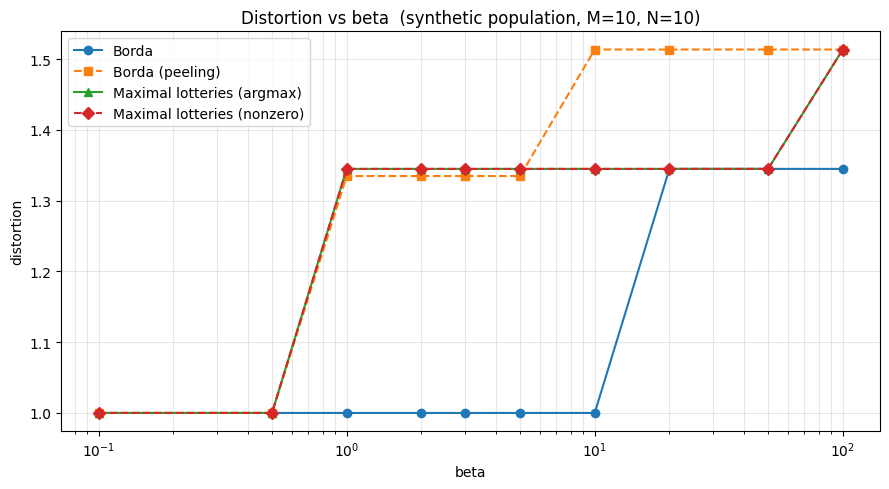

In [24]:
style = {
    'borda':         dict(marker='o', linestyle='-',  label='Borda'),
    'borda_peeling': dict(marker='s', linestyle='--', label='Borda (peeling)'),
    'ml_argmax':     dict(marker='^', linestyle='-',  label='Maximal lotteries (argmax)'),
    'ml_nonzero':    dict(marker='D', linestyle='--', label='Maximal lotteries (nonzero)'),
}

fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, distortions[m], **kw)

ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Distortion vs beta  (synthetic population, M={M}, N={N})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Same comparison across five additional populations

In [25]:
def compute_distortions(utilities, voter_dist, betas, cand_dist=None):
    V, C = utilities.shape
    avg_utils = voter_dist @ utilities
    true_rank = np.argsort(-avg_utils)
    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    out = {m: [] for m in ['borda', 'borda_peeling', 'ml_argmax', 'ml_nonzero']}
    for b in betas:
        P_b = win_rate_matrix(utilities, voter_dist, beta=b)

        out['borda'].append(
            leaderboard_dist(borda_from_P(P_b, cand_dist), true_rank, avg_utils)[0])

        out['borda_peeling'].append(
            leaderboard_dist(borda_peeling_from_P(P_b, cand_dist), true_rank, avg_utils)[0])

        try:
            _, r = argmax_lottery_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
            out['ml_argmax'].append(leaderboard_dist(r, true_rank, avg_utils)[0])
        except RuntimeError:
            out['ml_argmax'].append(float('nan'))

        try:
            _, r = nonzero_max_from_population_utilities(utilities, voter_dist=voter_dist, beta=b)
            out['ml_nonzero'].append(leaderboard_dist(r, true_rank, avg_utils)[0])
        except RuntimeError:
            out['ml_nonzero'].append(float('nan'))

    return out


extra_seeds = [0, 7, 13, 99, 2024]
all_results = []

for seed in extra_seeds:
    rng_s = np.random.default_rng(seed)
    utils_s = rng_s.standard_normal((N, M))
    vdist_s = np.ones(N, dtype=float) / N
    all_results.append((seed, compute_distortions(utils_s, vdist_s, betas)))
    print(f"seed {seed} done")

seed 0 done
seed 7 done
seed 13 done
seed 99 done
seed 2024 done


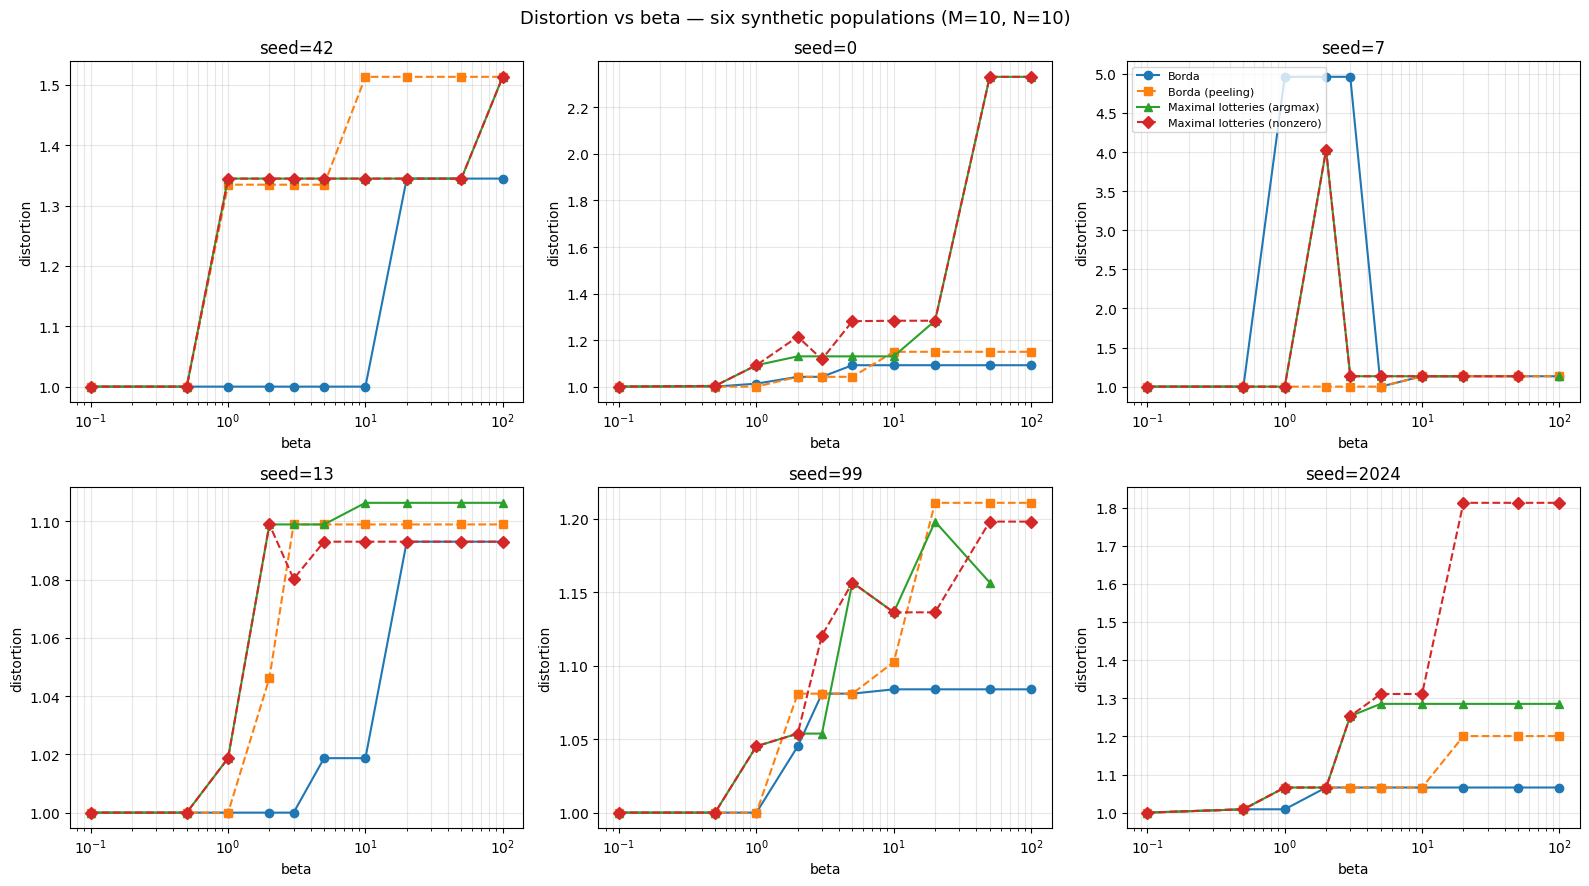

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=False)
axes = axes.flat

# first panel: original seed-42 population
panels = [(42, distortions)] + all_results

for ax, (seed, d) in zip(axes, panels):
    for m, kw in style.items():
        ax.plot(betas, d[m], **kw)
    ax.set_xscale('log')
    ax.set_title(f'seed={seed}')
    ax.set_xlabel('beta')
    ax.set_ylabel('distortion')
    ax.grid(True, which='both', alpha=0.3)

axes[2].legend(loc='upper left', fontsize=8)
fig.suptitle(f'Distortion vs beta — six synthetic populations (M={M}, N={N})', fontsize=13)
plt.tight_layout()
plt.show()